# 原来的code，compare all results
# get到Gurobi license 后再恢复
from pathlib import Path
import os
import sys

_here = Path.cwd().resolve()
_repo_root = next(path for path in (_here, *_here.parents) if (path / "configs" / "cfg.py").exists())
os.chdir(_repo_root)
sys.path.insert(0, str(_repo_root))

import matplotlib.pyplot as plt
from IPython.display import display

from scripts.compare import compare_records
from utils.run_artifacts import load_experiment_context
cfg, run_dir = load_experiment_context("artifacts/runs/20260510_172102_43adfd99")
result = compare_records(cfg, run_dir)
display(result["metrics_df"])
display(result["economic_table"])
display(result["safety_table"])

_plot_specs = [
    ("1. 电价", "compare_price"),
    ("2. 电压", "compare_voltage"),
    ("3. 净负荷", "compare_net_load"),
    ("4. 总体储能充放功率与 SoC", "compare_battery_soc"),
    ("5. 电力电量平衡", "compare_power_balance"),
]
for title, name in _plot_specs:
    print(title)
    display(result["figures"][name])
    plt.close(result["figures"][name])


跳过缺失结果: perfect/MISOCP
跳过缺失结果: lstm/ADMM_MPC
本次参与 compare 的结果:
- perfect/LOCAL_MPC
- lstm/LOCAL_MPC
- lstm/MADRL_BASE
- lstm/MADRL_PENALTY
- lstm/MADRL_PROJECTION


D:\RL_Thesis_Project\MADRL_ESS\utils\records.py:392: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles=[], labels=[], loc="upper right")


,controller,soc_mode,storage_charge_cost_total_eur,storage_discharge_revenue_total_eur,storage_profit_total_eur,storage_objective_total_eur,system_other_cost_eur,total_eur,soc_penalty_total,voltage_penalty_total,...,voltage_step_delta_p95_pu,voltage_step_delta_max_pu,voltage_spread_mean_pu,voltage_spread_max_pu,trafo_overload_steps,trafo_loading_max_pct,feeder_netload_ramp_mean_abs_kw,feeder_netload_ramp_max_kw,battery_net_power_kw_mean_abs,returned_primary_objective_eur
0,Local MPC + Perfect Forecast,continuous,900.239625,1476.654497,576.414872,-576.414872,0.0,-576.414875,7.804380,0.000077,...,0.019089,0.065087,0.005663,0.039240,157,170.051788,33.020977,312.749985,44.195540,-576.414875
1,Local MPC + LSTM Forecast,continuous,390.095373,567.072247,176.976874,-176.976874,0.0,-176.976873,4.131877,0.000607,...,0.014518,0.053593,0.004822,0.039006,94,144.983826,26.415871,275.681580,24.648208,-176.976873
2,MADRL + No Safety + LSTM Forecast,continuous,868.978362,1210.098531,341.120170,-341.120170,0.0,-341.120158,12.513687,0.000000,...,0.014853,0.049577,0.007802,0.041424,31,163.099731,28.242556,157.988476,38.858510,-341.120158
3,MADRL + Safety Penalty + LSTM Forecast,continuous,893.660466,627.574089,-266.086377,266.086377,0.0,266.086377,16.542461,0.000000,...,0.014555,0.051545,0.008751,0.052284,6,187.589111,27.918654,174.608273,29.461415,266.086377
4,MADRL + Safety Projection + LSTM Forecast,continuous,842.313696,1023.618263,181.304566,-181.304566,0.0,-181.304568,20.495191,0.000000,...,0.013001,0.052580,0.007148,0.043733,4,110.928726,25.496496,126.995071,36.987235,-181.304568


,controller,storage_discharge_revenue_total_eur,storage_charge_cost_total_eur,storage_profit_total_eur
0,Local MPC + Perfect Forecast,1476.654497,900.239625,576.414872
1,Local MPC + LSTM Forecast,567.072247,390.095373,176.976874
2,MADRL + No Safety + LSTM Forecast,1210.098531,868.978362,341.120170
3,MADRL + Safety Penalty + LSTM Forecast,627.574089,893.660466,-266.086377
4,MADRL + Safety Projection + LSTM Forecast,1023.618263,842.313696,181.304566


,controller,voltage_violation_steps,voltage_violation_bus_points,voltage_step_delta_p95_pu,voltage_step_delta_max_pu,voltage_spread_mean_pu,voltage_spread_max_pu,trafo_overload_steps,trafo_loading_max_pct,feeder_netload_ramp_mean_abs_kw,feeder_netload_ramp_max_kw
0,Local MPC + Perfect Forecast,24,24,0.019089,0.065087,0.005663,0.039240,157,170.051788,33.020977,312.749985
1,Local MPC + LSTM Forecast,22,22,0.014518,0.053593,0.004822,0.039006,94,144.983826,26.415871,275.681580
2,MADRL + No Safety + LSTM Forecast,7,7,0.014853,0.049577,0.007802,0.041424,31,163.099731,28.242556,157.988476
3,MADRL + Safety Penalty + LSTM Forecast,0,0,0.014555,0.051545,0.008751,0.052284,6,187.589111,27.918654,174.608273
4,MADRL + Safety Projection + LSTM Forecast,0,0,0.013001,0.052580,0.007148,0.043733,4,110.928726,25.496496,126.995071


1. 电价


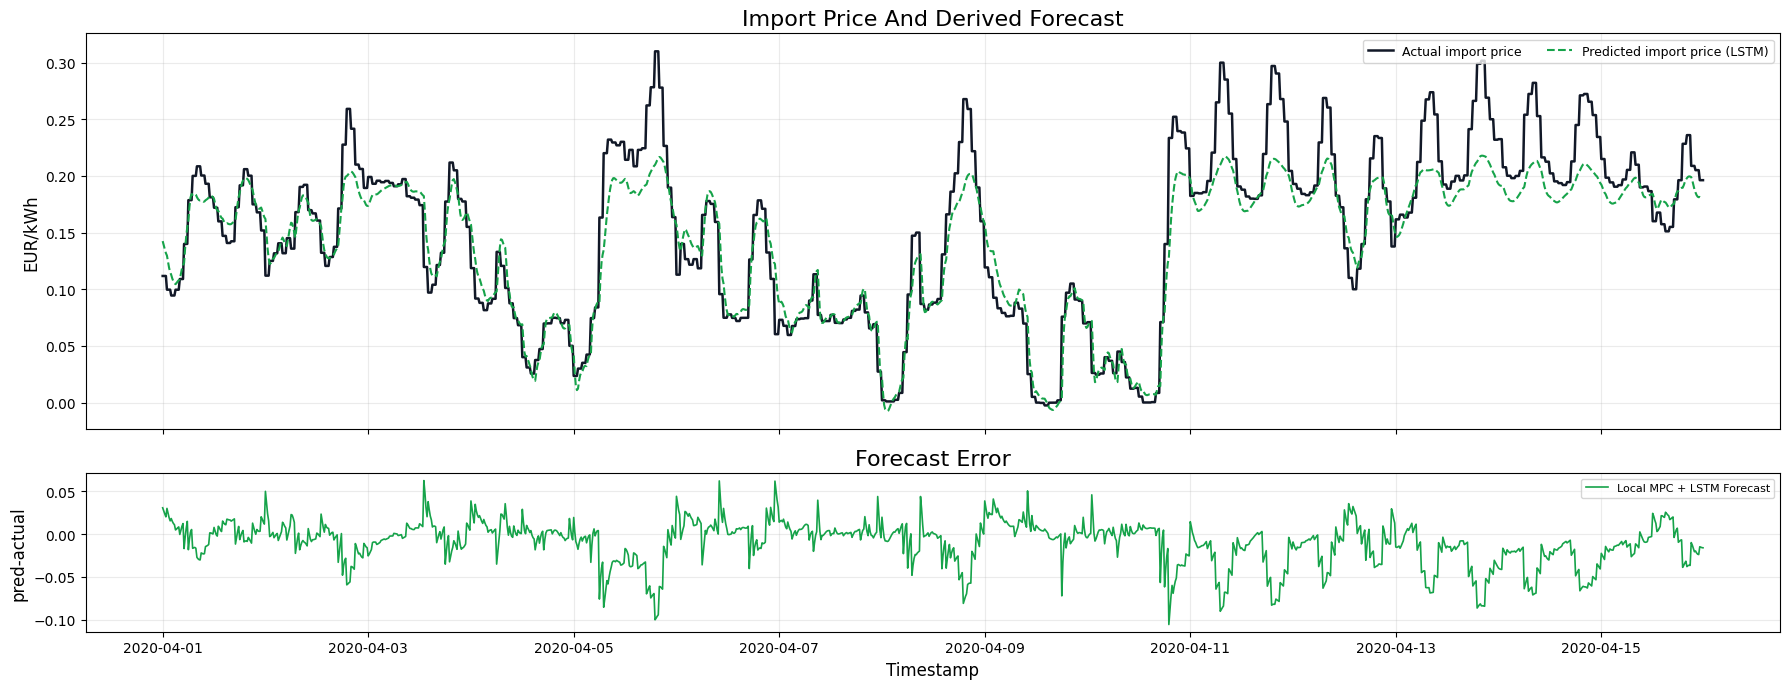

2. 电压


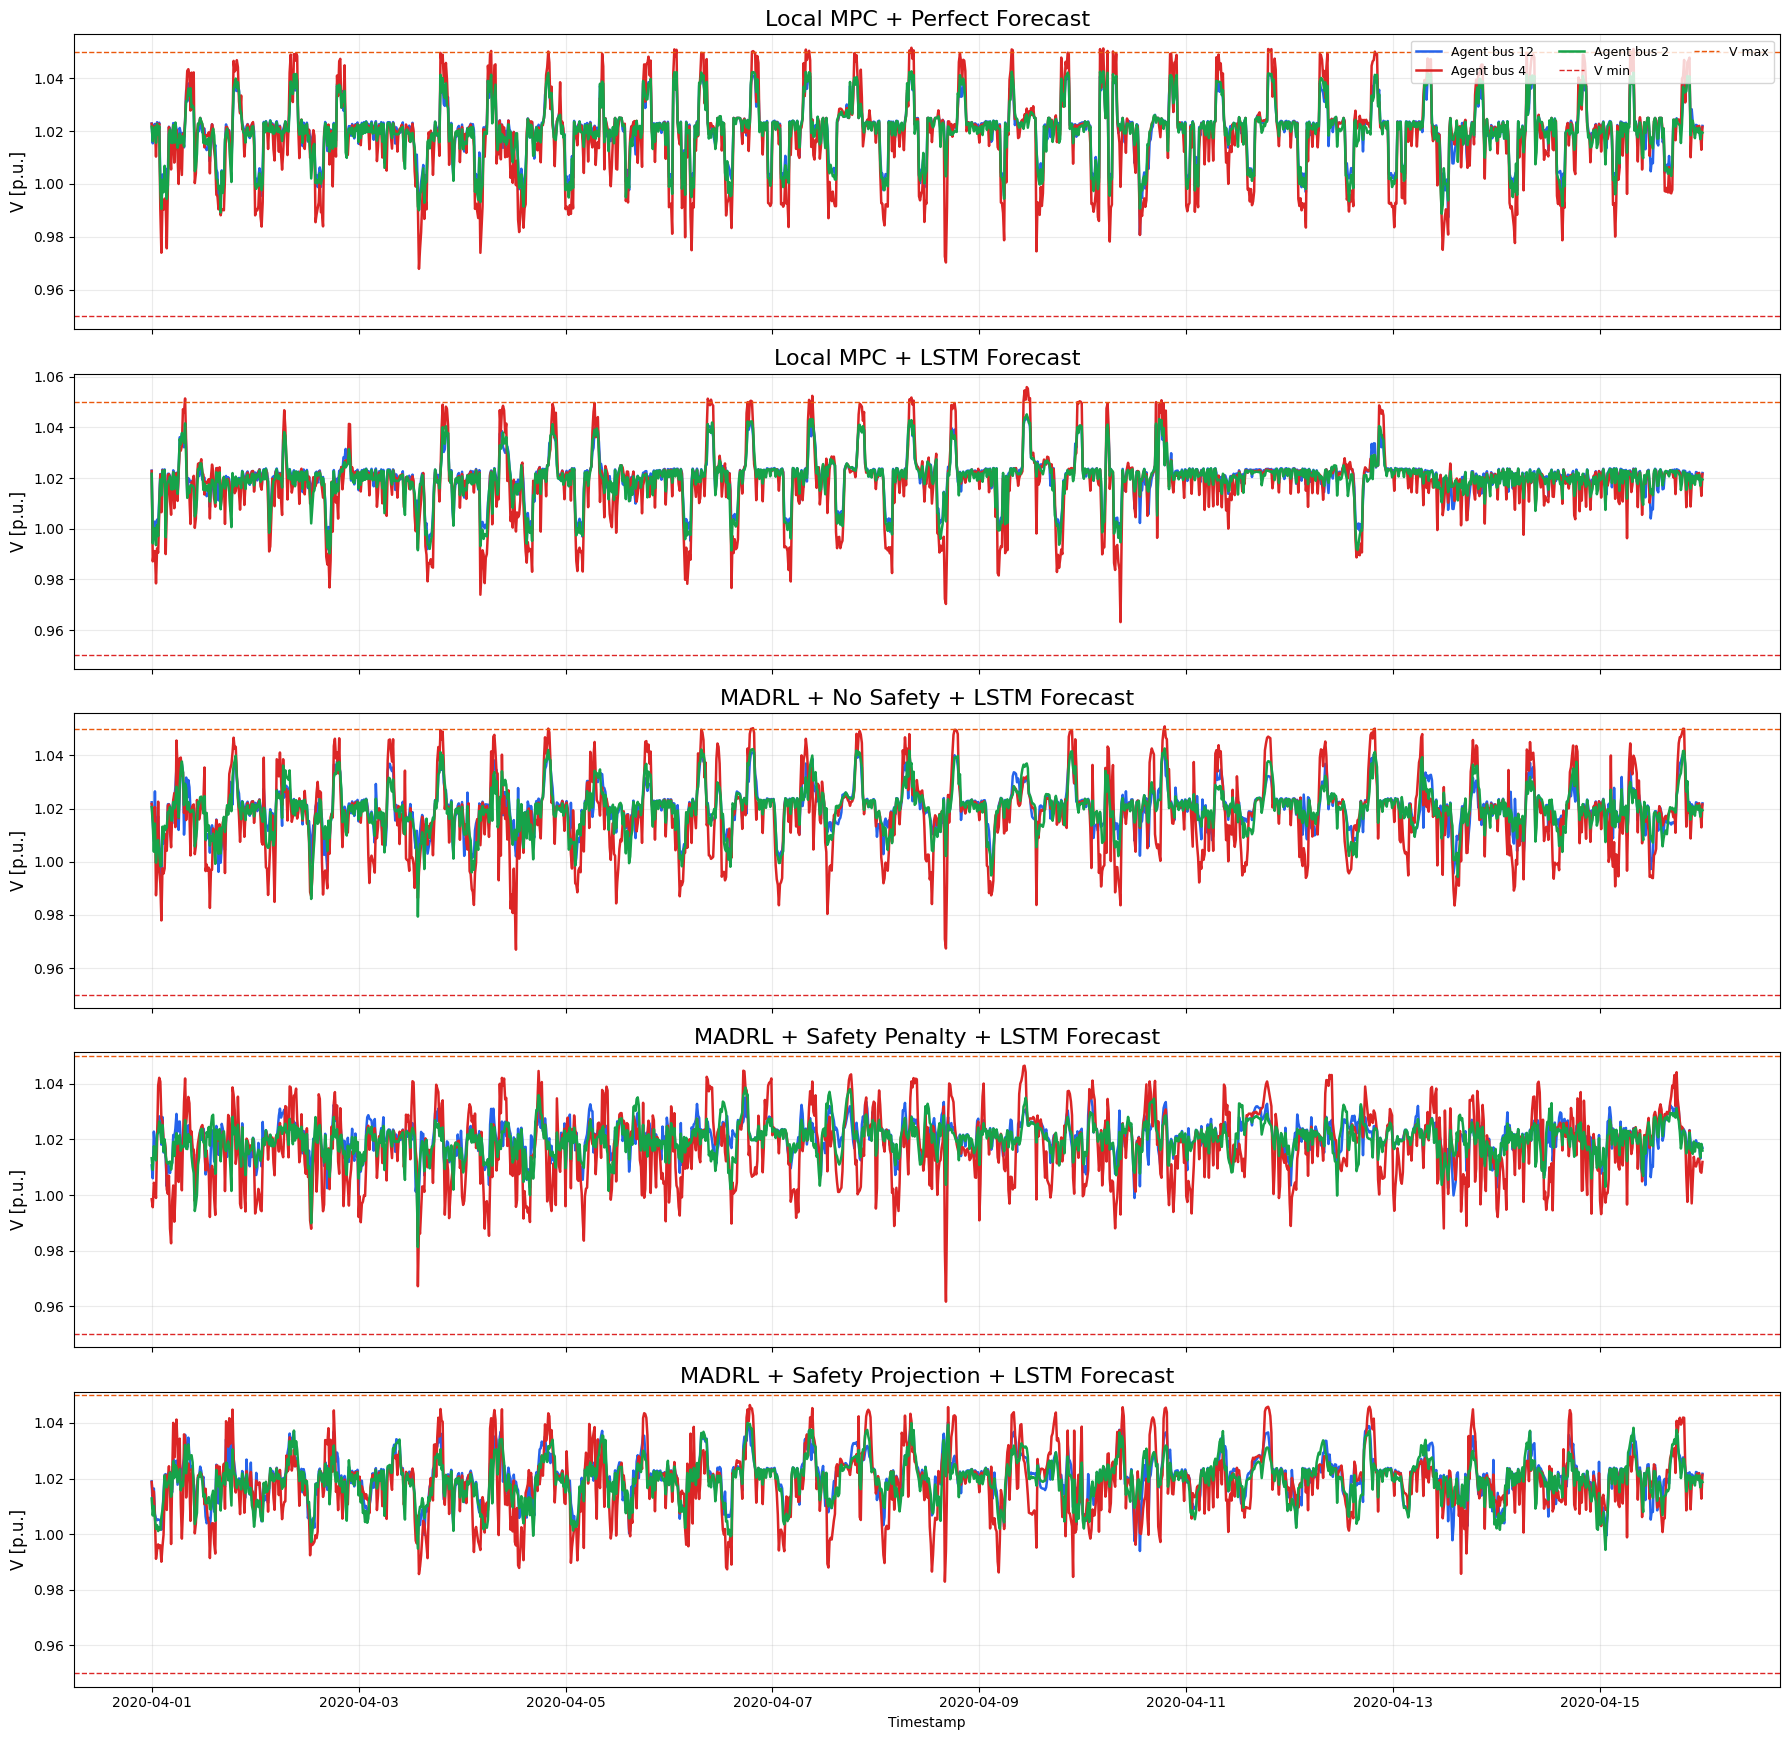

3. 净负荷


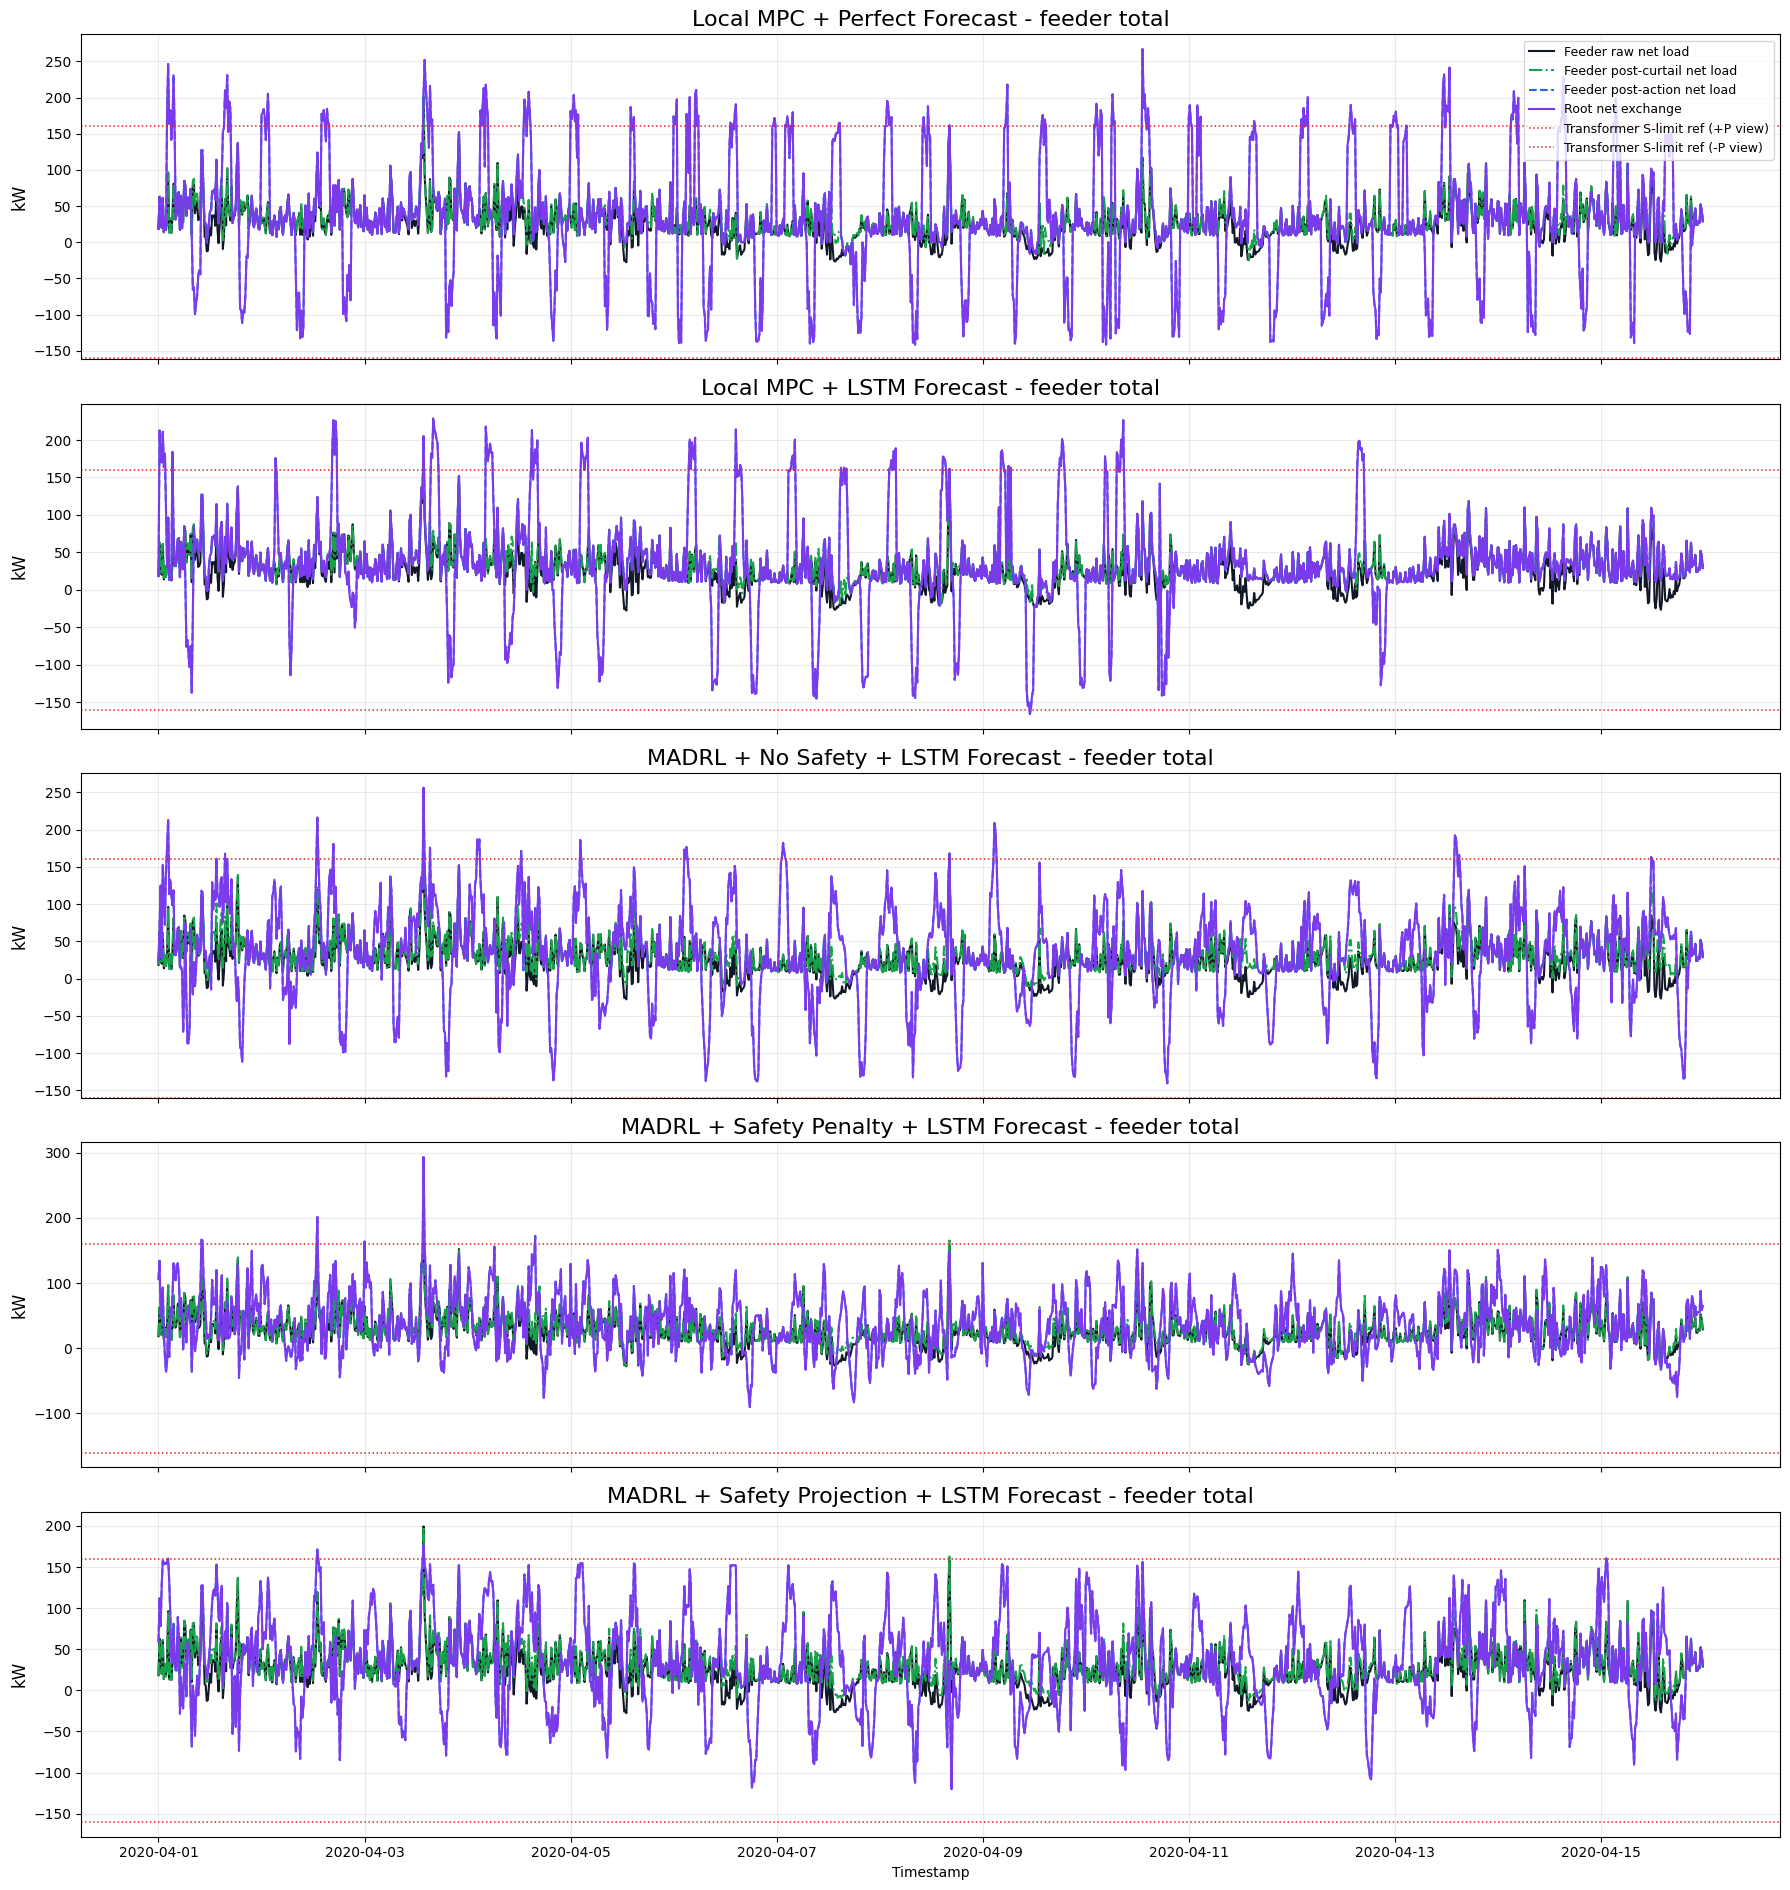

4. 总体储能充放功率与 SoC


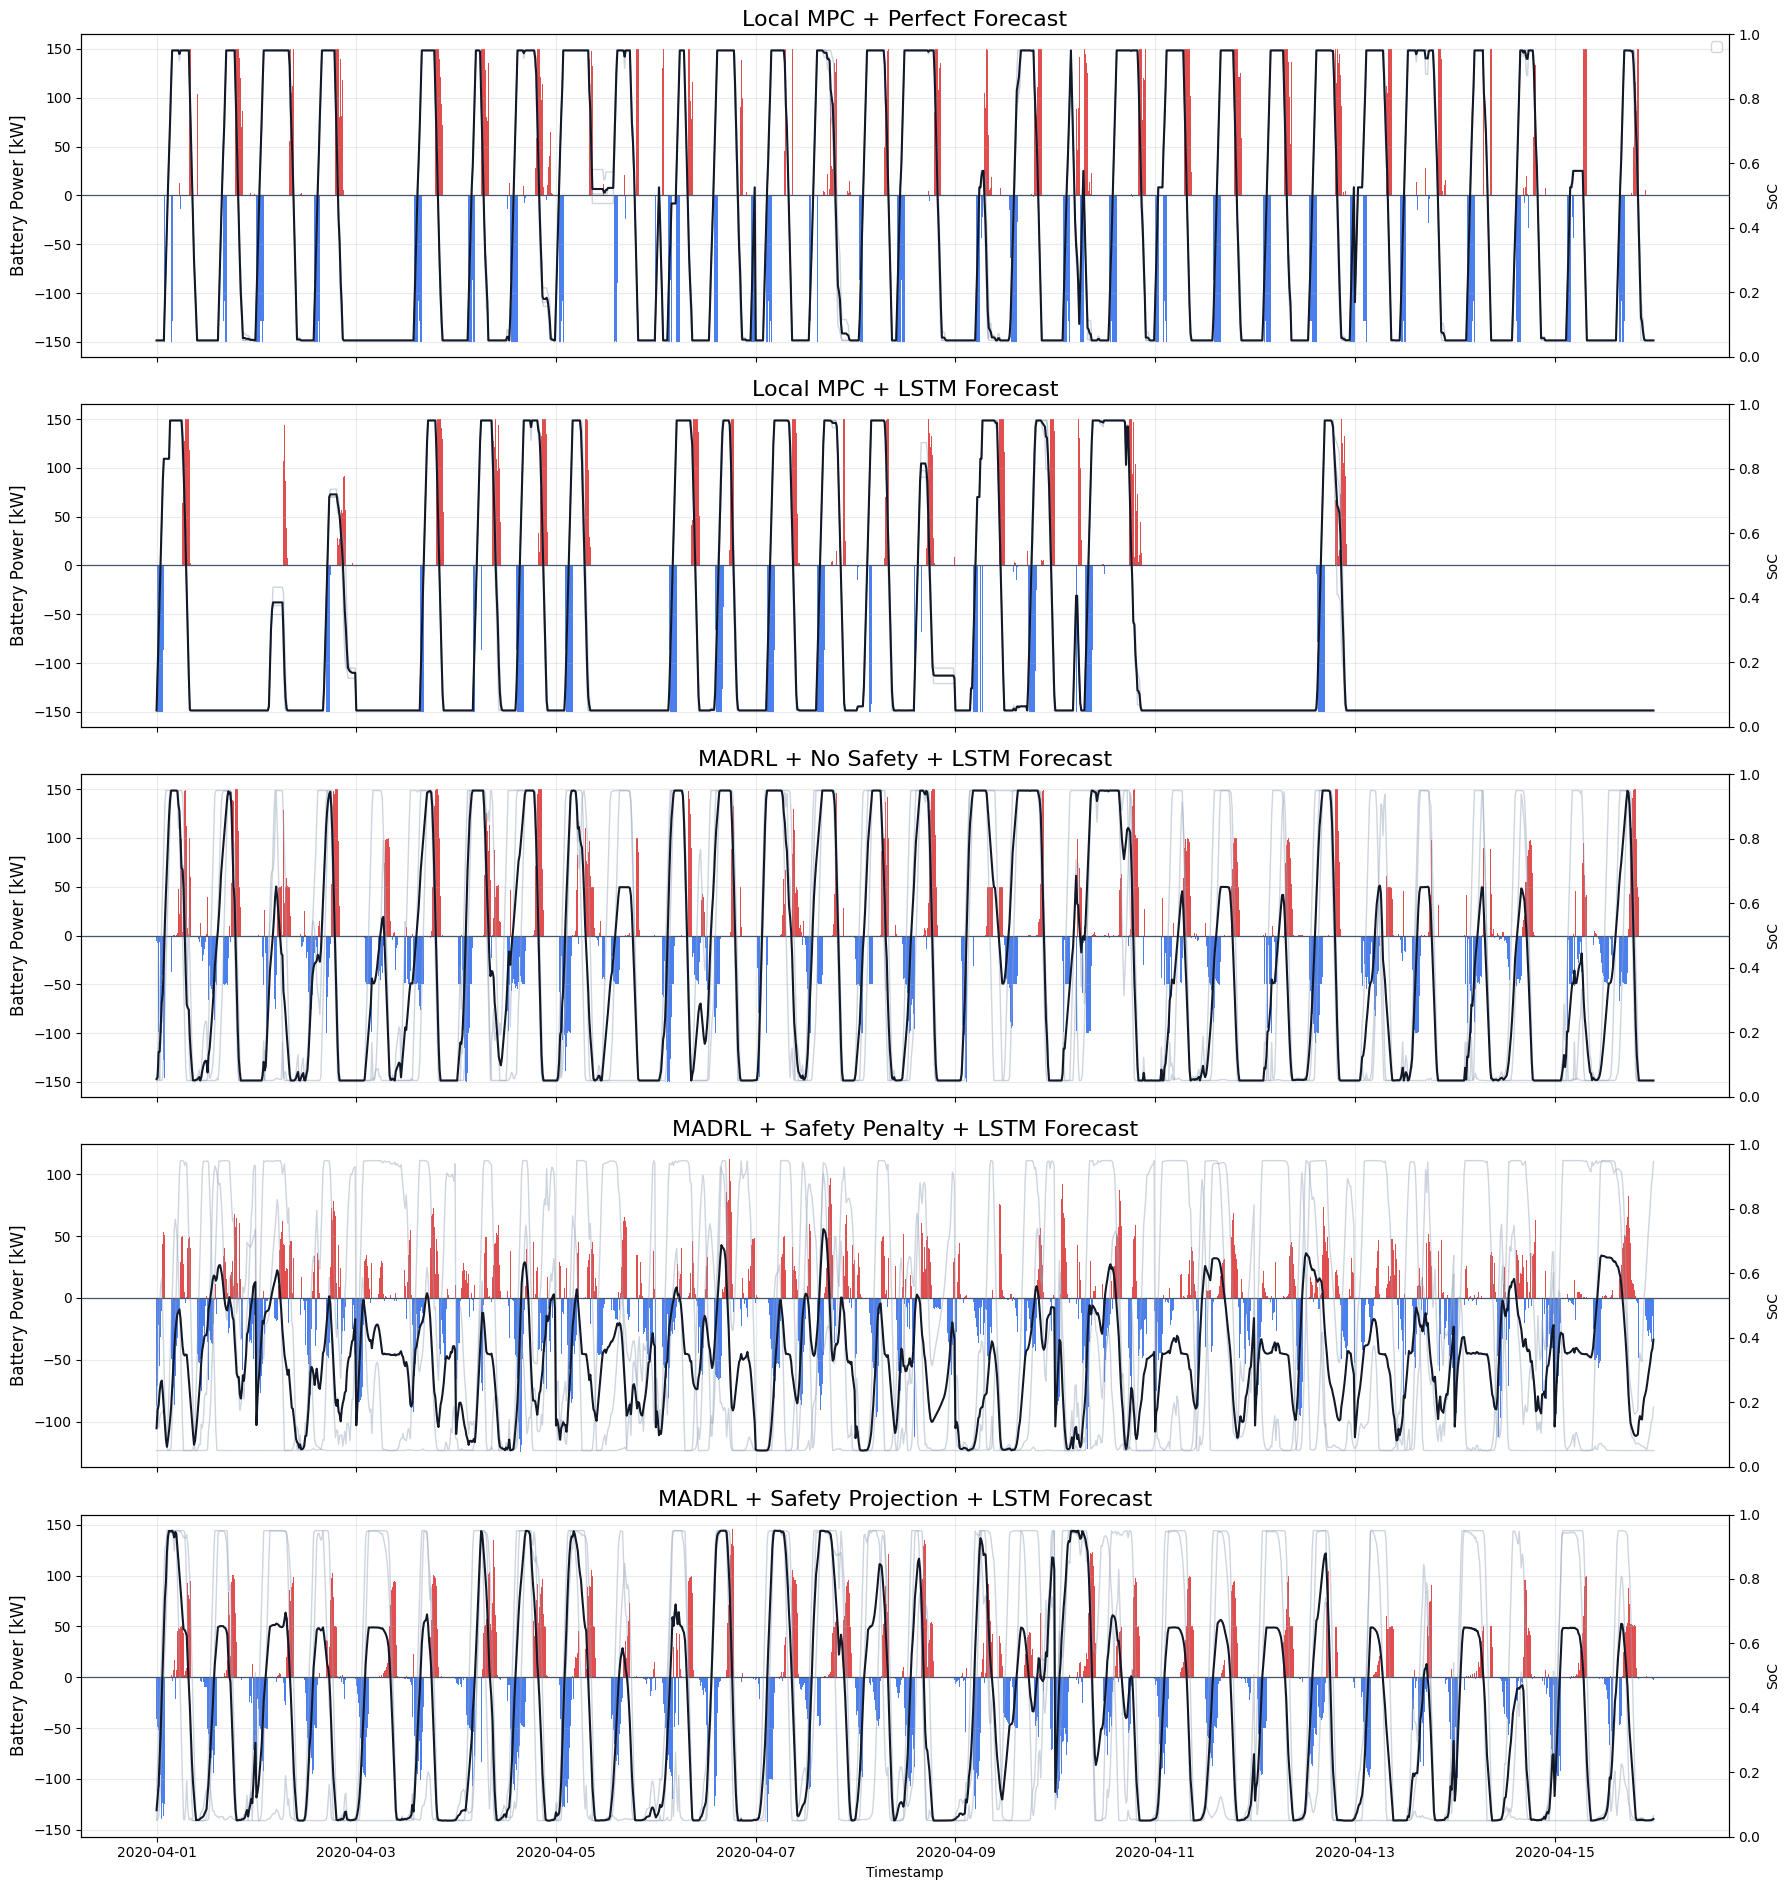

5. 电力电量平衡


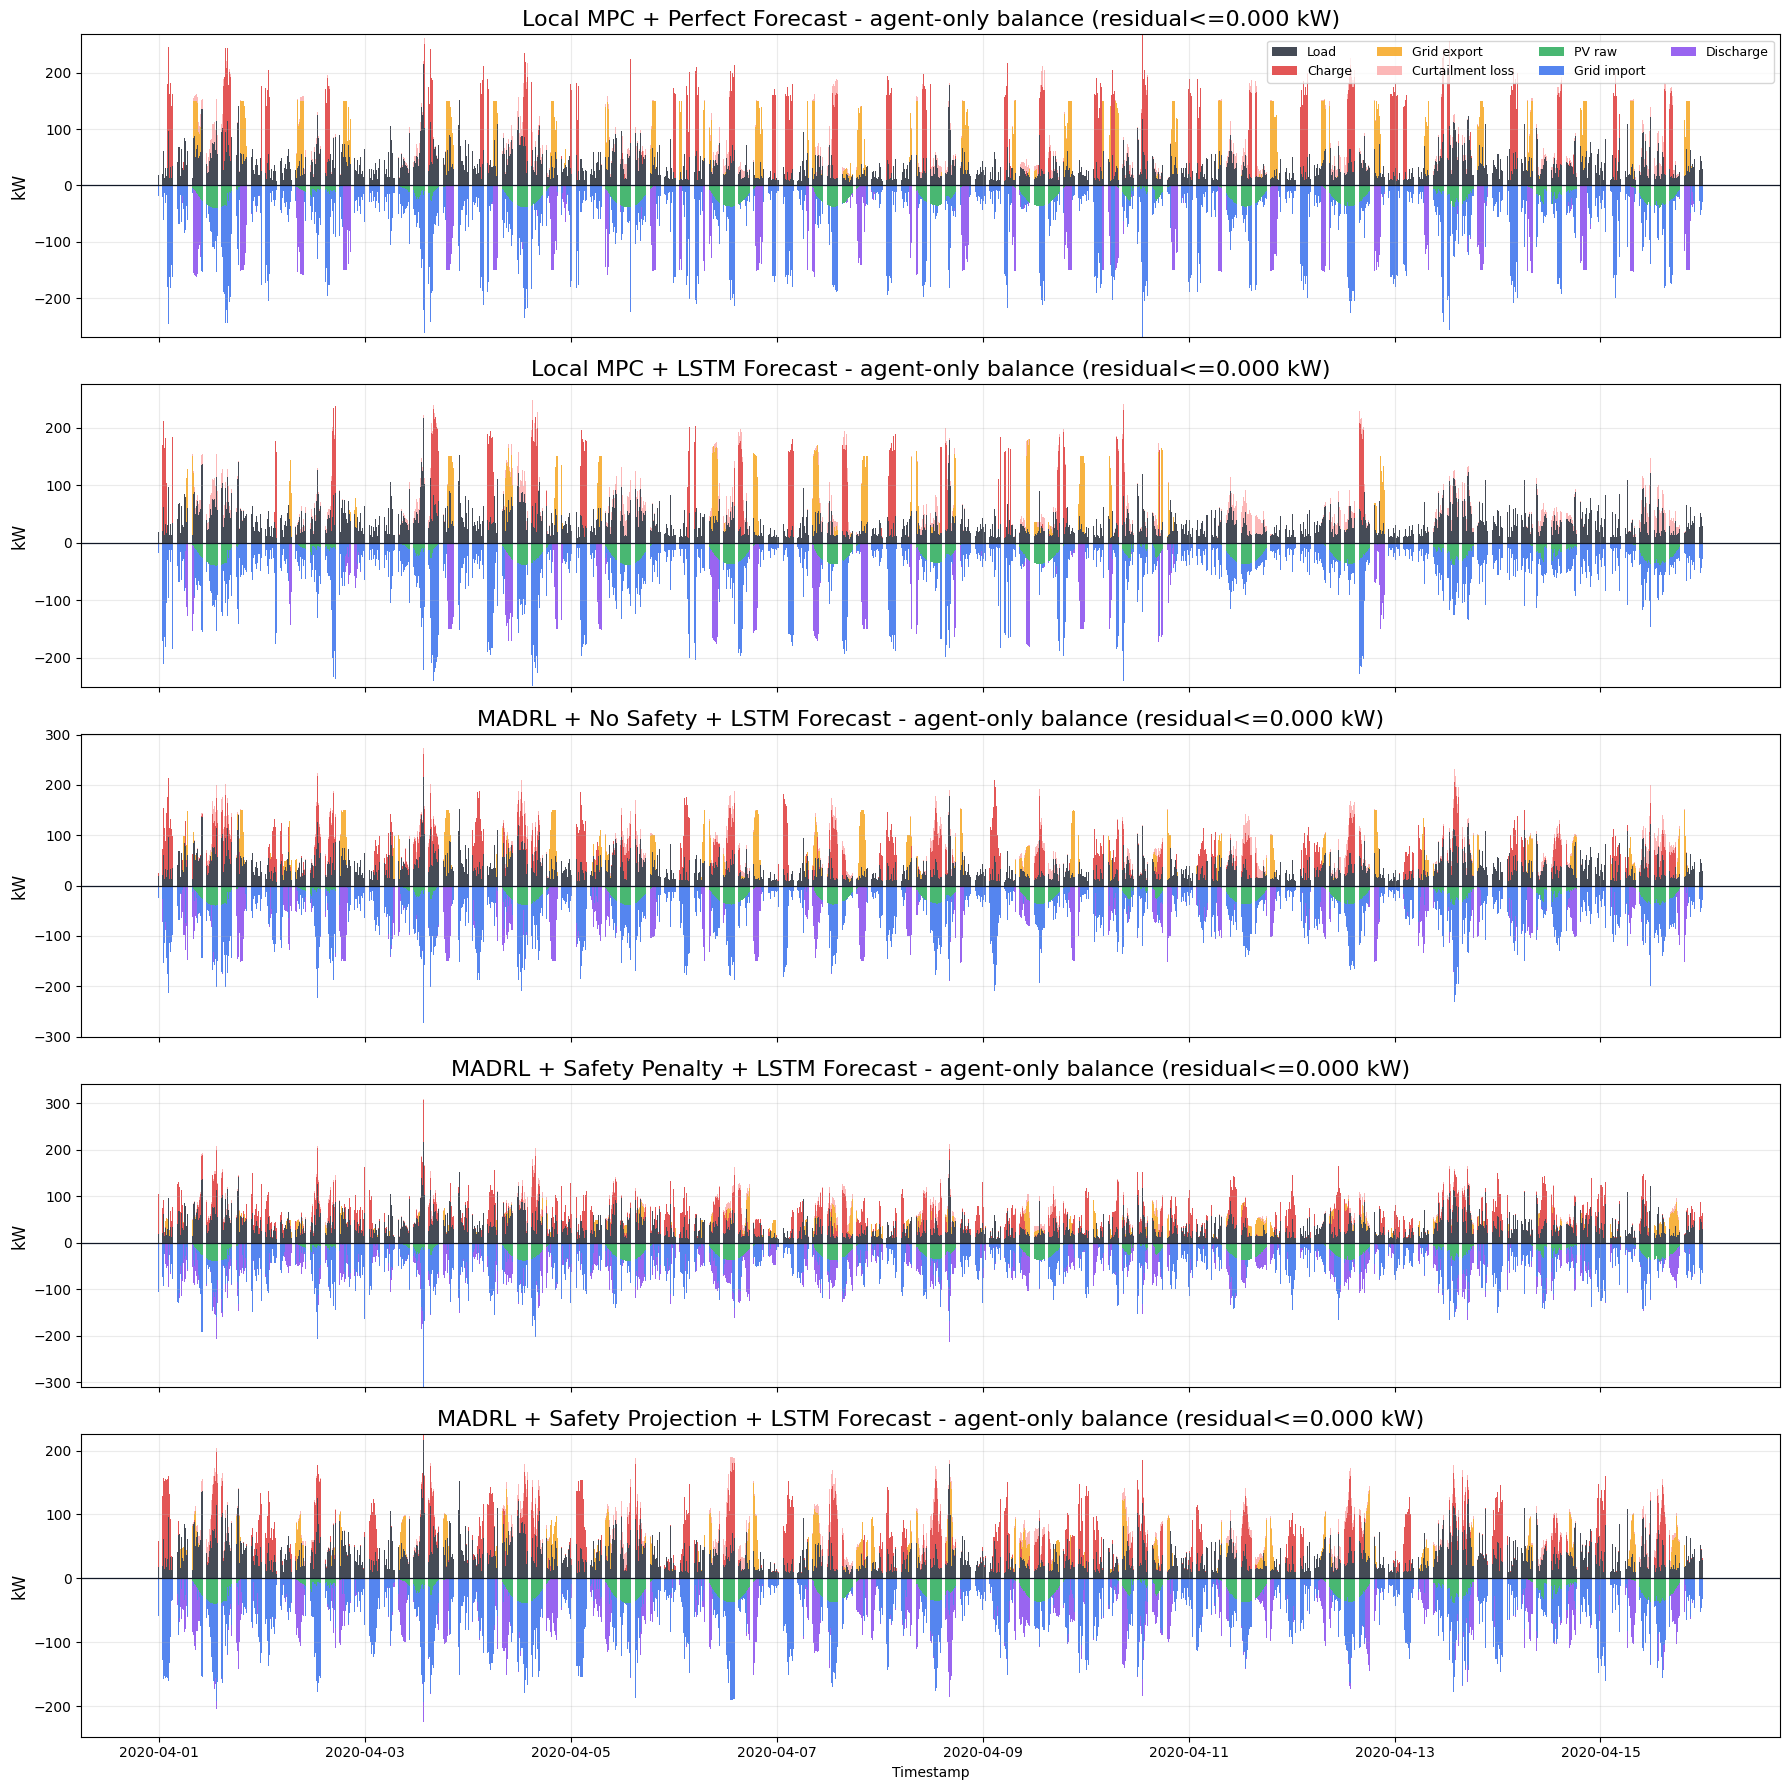

In [4]:
from pathlib import Path
import os
import sys

_here = Path.cwd().resolve()
_repo_root = next(path for path in (_here, *_here.parents) if (path / "configs" / "cfg.py").exists())
os.chdir(_repo_root)
sys.path.insert(0, str(_repo_root))

import matplotlib.pyplot as plt
from IPython.display import display

import scripts.compare as compare_module
from utils.run_artifacts import load_experiment_context

cfg, run_dir = load_experiment_context("artifacts/runs/20260510_172102_43adfd99")
run_dir = Path(run_dir)

# 只保留已经存在 record/manifest.json 的 scheme
available_schemes = []

for mode, controller in compare_module.COMPARE_SCHEMES:
    manifest_path = run_dir / "results" / mode / controller / "record" / "manifest.json"
    if manifest_path.exists():
        available_schemes.append((mode, controller))
    else:
        print(f"跳过缺失结果: {mode}/{controller}")

print("本次参与 compare 的结果:")
for mode, controller in available_schemes:
    print(f"- {mode}/{controller}")

# 覆盖默认 COMPARE_SCHEMES
compare_module.COMPARE_SCHEMES = available_schemes

# 运行 compare
result = compare_module.compare_records(cfg, run_dir)

display(result["metrics_df"])
display(result["economic_table"])
display(result["safety_table"])

_plot_specs = [
    ("1. 电价", "compare_price"),
    ("2. 电压", "compare_voltage"),
    ("3. 净负荷", "compare_net_load"),
    ("4. 总体储能充放功率与 SoC", "compare_battery_soc"),
    ("5. 电力电量平衡", "compare_power_balance"),
]

for title, name in _plot_specs:
    print(title)
    if name in result["figures"]:
        display(result["figures"][name])
        plt.close(result["figures"][name])
    else:
        print(f"图不存在，跳过: {name}")